

---

<center>
<h1><b><i>CODVEDA TECHNOLOGIES</b></h1>
<h1><b>Machine Learning INTERNSHIP TASK 03 | LEVEL 02(Intermediate)</b></h1>
<h1><b>TOPIC: K-MEANS CLUSTERING</b></h1>


---


<h2>Submitted by: Muhammad Usman</h2></i></center>


---





> Importing ALL Necessary Libraries and Modules Used In Task



In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster  import KMeans
from sklearn.decomposition import PCA

<center><h2><b>STEP 01: DATASET LOADING AND PREPROCESSING</b></h2></center>

>Dropping Target from Iris Dataset to make unsupervised learning

In [39]:

data=pd.read_csv('C:/Users/Dell/Downloads/Data Set For Task-20250403T150626Z-001/Data Set For Task/1) iris.csv')
data.columns


Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

> Dropping the Column Species from Iris Dataset

In [40]:
data1=data.drop(columns=['species'])
data1.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

>Scaling the Dataset For having mean =0 and Varince =1 for all features

In [41]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data1)
#for ensuring scaling
df_data=pd.DataFrame(scaled_data)
df_data.head()

,0,1,2,3
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


<center><h2><b>STEP 02: OPTIMAL NO OF CLUSTERS WITH ELBOW METHOD</b></h2></center>

C:\Users\Dell\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\c

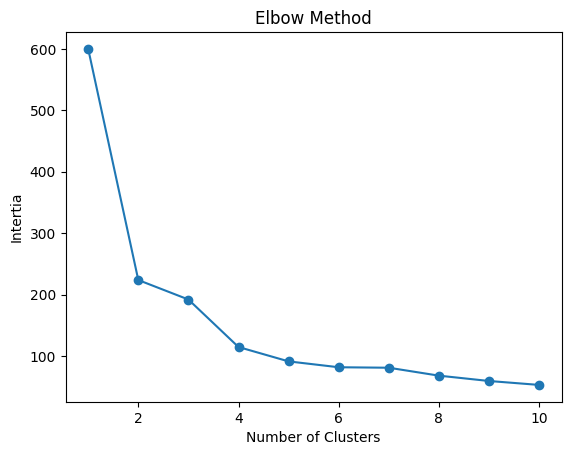

In [42]:
inertia=[]
k_range=range(1,11)

for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(k_range,inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Intertia')
plt.title('Elbow Method')
plt.show()

<center><h2>WE FOUND NUMBER OF CLUSTERS SHOULD BE 3</h2></center>

<b><h3>Real Training of the Model as we found the total number of clusters should be equal  to 3 from elbow method above, for optimal clustering</h3></b>

In [43]:
kmeans=KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(scaled_data)
df_data['cluster'] = y_kmeans
df_data

C:\Users\Dell\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,0,1,2,3,cluster
0,-0.900681,1.032057,-1.341272,-1.312977,1
1,-1.143017,-0.124958,-1.341272,-1.312977,2
2,-1.385353,0.337848,-1.398138,-1.312977,2
3,-1.506521,0.106445,-1.284407,-1.312977,2
4,-1.021849,1.263460,-1.341272,-1.312977,1
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,0
146,0.553333,-1.281972,0.705893,0.922064,0
147,0.795669,-0.124958,0.819624,1.053537,0
148,0.432165,0.800654,0.933356,1.447956,0


<center><h2><b>STEP 03: VISUALIZING CLUSTERS AND INTERPRETING RESULTS</b></h2></center>

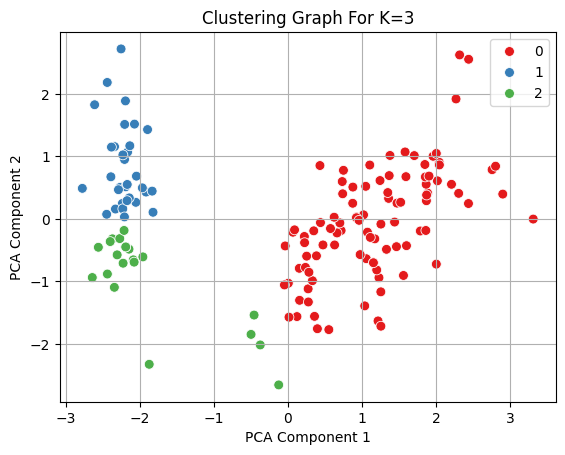

In [45]:
pca = PCA(2)
data_pca = pca.fit_transform(scaled_data)
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1], hue=y_kmeans, palette='Set1', s=50)
plt.title("Clustering Graph For K=3")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()